In [9]:
import jax.random as jrand
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt

from gvabm.city_data import subsampled_city_data, subsampled_city_data_names, subsample_weights
city_ids = ['_'.join(name) for name in subsampled_city_data_names]

import numpy as np


In [16]:
with open('data/arm_sweep_stats.pkl', 'rb') as f:
    arm_sweep_stats = pickle.load(f)
arm_sweep_stats = np.stack(arm_sweep_stats)

with open('data/pop_dens_sweep_stats.pkl', 'rb') as f:
    pop_dens_sweep_stats = pickle.load(f)
pop_dens_sweep_stats = np.stack(pop_dens_sweep_stats)

In [17]:
arm_sweep_values = np.linspace(0.0, 0.6, 100)
pop_dens_sweep_values = np.linspace(10, 10000, 100)

arm_sweep_p_event = arm_sweep_stats[:, :, 2]
pop_dens_sweep_p_event = pop_dens_sweep_stats[:, :, 2]

In [20]:
#convert p_event to logit scale
arm_sweep_p_event_logit = np.log(arm_sweep_p_event / (1 - arm_sweep_p_event))
pop_dens_sweep_p_event_logit = np.log(pop_dens_sweep_p_event / (1 - pop_dens_sweep_p_event))

In [18]:
arm_sweep_p_event.shape
sample_arm_sweep_vals = arm_sweep_values[:, None].repeat(arm_sweep_p_event.shape[1], axis=1)
sample_pop_dens_sweep_vals = pop_dens_sweep_values[:, None].repeat(pop_dens_sweep_p_event.shape[1], axis=1)

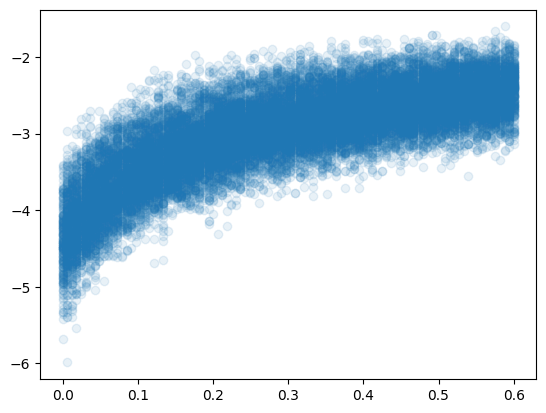

In [ ]:
plt.scatter(sample_arm_sweep_vals.flatten(), arm_sweep_p_event_logit.flatten(), alpha=0.1)
plt.scatter(sample_pop_dens_sweep_vals.flatten(), pop_dens_sweep_p_event_logit.flatten(), alpha=0.1)
plt.show()

In [44]:
sample_arm_sweep_vals = sample_arm_sweep_vals.flatten()
arm_sweep_p_event = arm_sweep_p_event.flatten()

nanmask = np.isnan(arm_sweep_p_event)
sample_arm_sweep_vals = sample_arm_sweep_vals[~nanmask]
arm_sweep_p_event = arm_sweep_p_event[~nanmask]

sample_pop_dens_sweep_vals = sample_pop_dens_sweep_vals.flatten()
pop_dens_sweep_p_event = pop_dens_sweep_p_event.flatten()

nanmask = np.isnan(pop_dens_sweep_p_event)
sample_pop_dens_sweep_vals = sample_pop_dens_sweep_vals[~nanmask]
pop_dens_sweep_p_event = pop_dens_sweep_p_event[~nanmask]

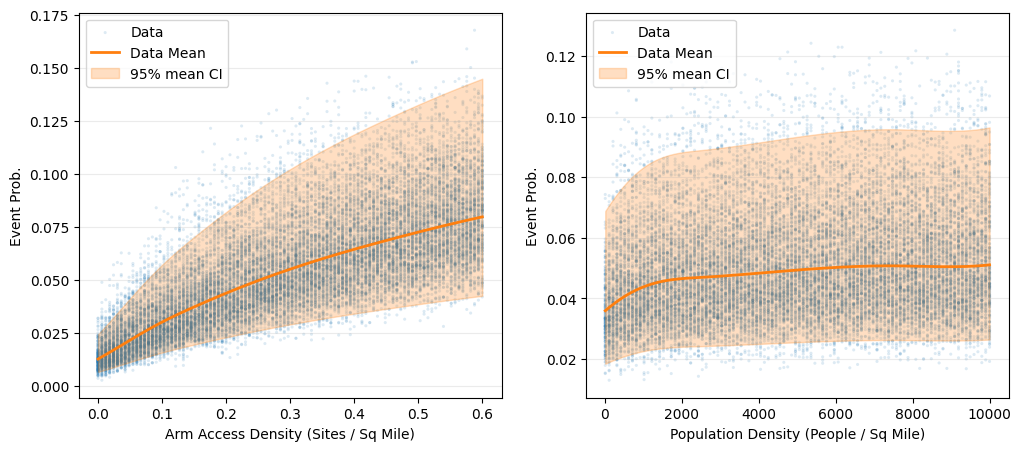

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_weighted_spline_prob_ci(
    sample_arm_sweep_vals,
    arm_sweep_p_event,
    w=np.ones(sample_arm_sweep_vals.flatten().shape),
    ax=axes[0],)
plot_weighted_spline_prob_ci(
    sample_pop_dens_sweep_vals,
    pop_dens_sweep_p_event,
    w=np.ones(sample_pop_dens_sweep_vals.flatten().shape),
    ax=axes[1],)
axes[0].set_ylabel('Event Prob.')
axes[0].set_xlabel('Arm Access Density (Sites / Sq Mile)')
axes[1].set_ylabel('Event Prob.')
axes[1].set_xlabel('Population Density (People / Sq Mile)')
fig.savefig('images/arm_pop_dens_spline_plots.png', dpi=300)
plt.show()

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from patsy import dmatrix
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.special import expit, logit

def plot_weighted_spline_prob_ci(x, y, w,
                                 df=6,
                                 n_grid=300,
                                 alpha=0.05,
                                 clamp_eps=1e-6,
                                 scatter_alpha=0.15,
                                 scatter_size_scale=50,
                                 figsize=(9,6),
                                 ax=None):

    # Convert to numpy arrays
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    w = np.asarray(w).ravel()
    assert x.shape == y.shape == w.shape, "x, y, w must have same shape"
    
    # Clamp y away from 0 and 1 to make logit well-defined
    y_clamped = np.clip(y, clamp_eps, 1 - clamp_eps)
    y_logit = logit(y_clamped)
    
    # x_df = pd.DataFrame({"x": x})
    
    # X_spline = dmatrix(f"bs(x, df={df}, degree=3, include_intercept=False)",
    #                    x_df, return_type='dataframe')
    
    # # Add constant column for intercept
    # X = sm.add_constant(X_spline, has_constant='add')
    # wls_model = sm.WLS(y_logit, X)
    # wls_res = wls_model.fit()
    
    # # Prepare grid for smooth line
    x_grid = np.linspace(np.min(x), np.max(x), n_grid)
    xg_df = pd.DataFrame({"x": x_grid})
    # Xg_spline = dmatrix(f"bs(x, df={df}, degree=3, include_intercept=False)",
    #                     xg_df, return_type='dataframe')
    # Xg = sm.add_constant(Xg_spline, has_constant='add')
    
    # Get prediction object for the grid (this returns the mean and its CI on logit scale)
    df = pd.DataFrame({'x': x, 'y': y_logit, 'w': w})
    model = smf.wls("y ~ bs(x, df=6)", data=df, weights=df['w']).fit()
    pred = model.get_prediction(xg_df)
    pred_df = pred.summary_frame(alpha=alpha)  # contains mean, mean_se, mean_ci_lower, mean_ci_upper, obs_ci_*
    
    # Extract mean and mean CI on logit scale
    mean_logit = pred_df["mean"]
    ci_lower_logit = pred_df["obs_ci_lower"]
    ci_upper_logit = pred_df["obs_ci_upper"]
    
    # Back-transform to probability scale
    mean_prob = expit(mean_logit)
    ci_lower_prob = expit(ci_lower_logit)
    ci_upper_prob = expit(ci_upper_logit)
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    
    ax.scatter(x, y, s=5, alpha=scatter_alpha, edgecolor='none', label='Data')
    ax.plot(x_grid, mean_prob, color='C1', lw=2, label='Data Mean')
    ax.fill_between(x_grid, ci_lower_prob, ci_upper_prob, color='C1', alpha=0.25,
                    label=f'{int((1-alpha)*100)}% mean CI')
    
    # Labels and styling
    ax.set_xlabel('x')
    ax.set_ylabel('probability (y)')
    # ax.set_ylim(-0.02, 1.02)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='best')
    return (x_grid, mean_prob, ci_lower_prob, ci_upper_prob)


In [ ]:
with open('/home/andrew/abm_violence/paper_code/data/city_sample_stats.pkl', 'rb') as f:
    city_stat_dict = pickle.load(f)

data_tensor = np.stack([city_stat_dict[city_id] for city_id in city_ids], axis=0)


propensity = city_mean_val[:, 0]
expected_event_size = city_mean_val[:, 1]
event_prob = city_mean_val[:, 2]
p_loc = city_mean_val[:, 3]
p_weapon = city_mean_val[:, 4]
p_high_weapon = city_mean_val[:, 5]
#City list x ([propensity, expected_event_size, p_event, p_loc, p_weapon, p_high_weapon, access_count])

In [62]:
from gvabm.param_distr import CityParams
#['year', 'population', 'population_density', 'arm_count', 'arm_density'])
spoof_city = CityParams(year=2020, population=100000, population_density=1000, arm_count=-1, arm_density=0.2)


In [60]:
city_pop_size = np.array([c['params'].population for c in subsampled_city_data])
city_arm_density = np.array([c['params'].arm_density for c in subsampled_city_data])
city_pop_density = np.array([c['params'].population_density for c in subsampled_city_data])
has_event = np.array([len(c['events']) > 0 for c in subsampled_city_data])

In [64]:
city_pop_density.min(), city_pop_density.max()
city_arm_density.min(), city_arm_density.max()

(np.float64(0.0), np.float64(0.4519745222929936))

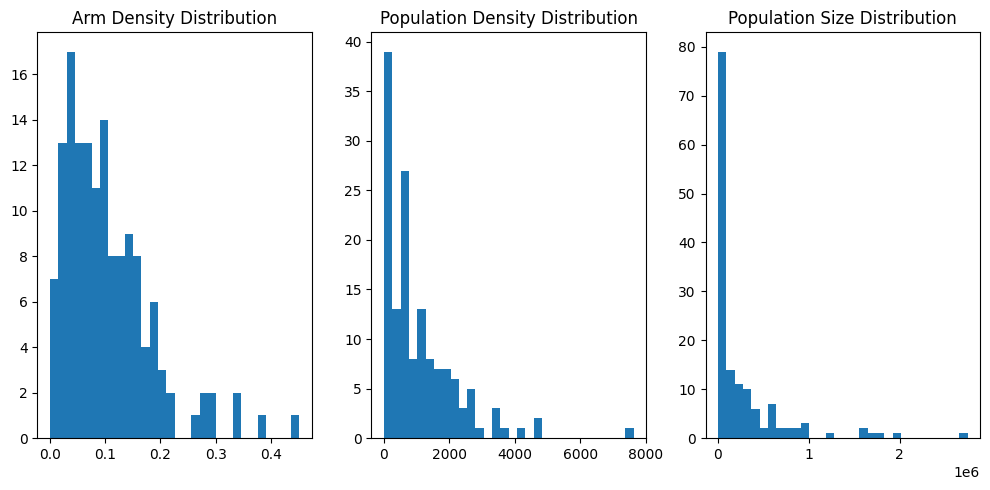

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].hist(city_arm_density[has_event], weights=subsample_weights[has_event], bins=30)
axes[0].set_title('Arm Density Distribution')
axes[1].hist(city_pop_density[has_event], weights=subsample_weights[has_event], bins=30)
axes[1].set_title('Population Density Distribution')
axes[2].hist(city_pop_size[has_event], weights=subsample_weights[has_event], bins=30)
axes[2].set_title('Population Size Distribution')
plt.tight_layout()
plt.show()

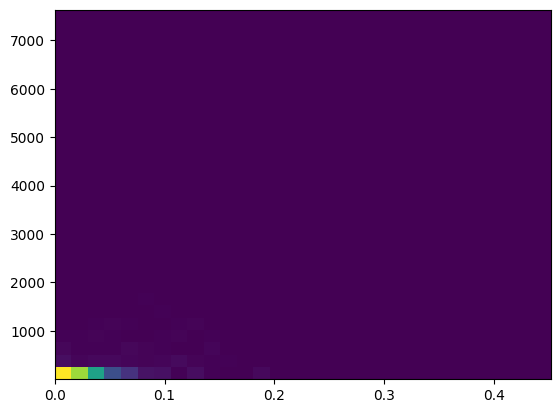

In [51]:
plt.hist2d(city_arm_density, city_pop_density, weights=subsample_weights, bins=30, density=True)
plt.show()

In [9]:
city_mean_val = np.nanmean(data_tensor, axis=1)
city_std_val = np.nanstd(data_tensor, axis=1)

event_prob_mean = city_mean_val[:, 2]
event_prob_std = city_std_val[:, 2]

In [39]:
event_prob = data_tensor[:, :, 2]  # City list x Sample list
sample_city_arm_density = np.array([c['params'].arm_density for c in subsampled_city_data])
sample_city_arm_density = np.repeat(sample_city_arm_density[:, None], event_prob.shape[1], axis=1)
sample_weights = subsample_weights  # City list x Sample list
sample_weights = np.repeat(sample_weights[:, None], event_prob.shape[1], axis=1)

In [40]:
import statsmodels.formula.api as smf
import pandas as pd
df = pd.DataFrame({'x': sample_city_arm_density.flatten(), 'y': event_prob.flatten(), 'w': sample_weights.flatten()})
model = smf.wls("y ~ bs(x, df=6)", data=df, weights=df['w']).fit()

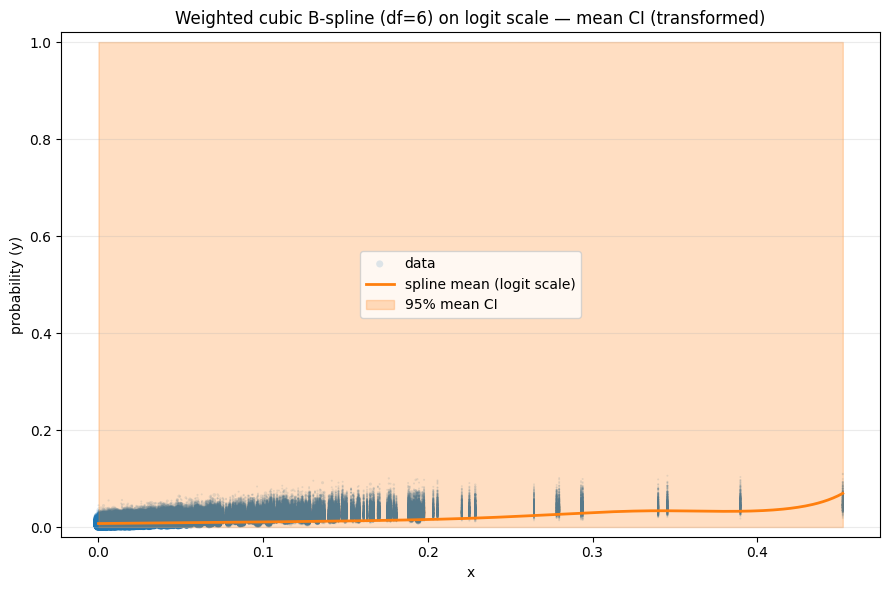

In [46]:
res, (xg, mean_p, lower_p, upper_p) = plot_weighted_spline_prob_ci(sample_city_arm_density.flatten(), event_prob.flatten(), sample_weights.flatten(), df=6)


In [33]:
x_vals = np.linspace(0, np.max(city_arm_density), 100)
res = model.get_prediction(pd.DataFrame({'x': x_vals}))

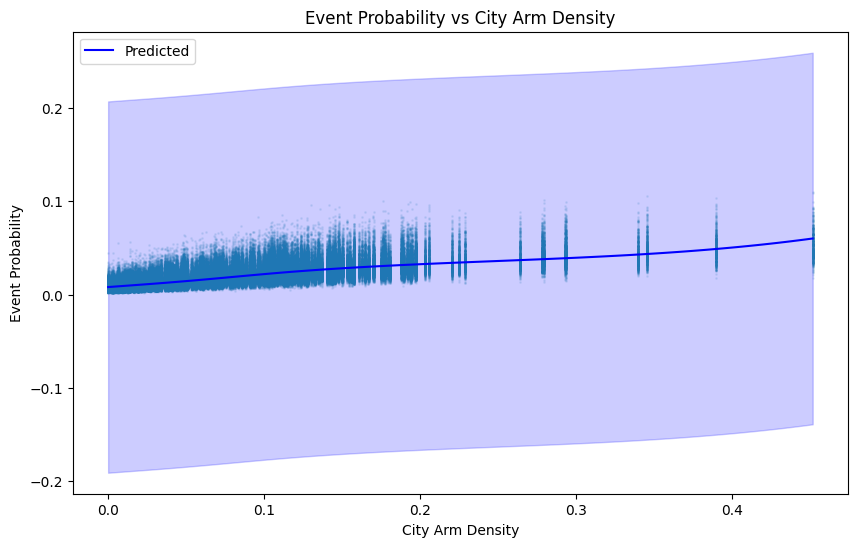

In [42]:
summary_frame = res.summary_frame(alpha=0.05)
y_vals = summary_frame['mean']
y_low = summary_frame['obs_ci_lower']
y_upp = summary_frame['obs_ci_upper']
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Predicted', color='blue')
plt.fill_between(x_vals, y_low, y_upp, color='blue', alpha=0.2)
# plt.scatter(city_arm_density[~has_event], event_prob_mean[~has_event], s=4, marker='o', color='red', label='No Event')
# plt.scatter(city_arm_density[has_event], event_prob_mean[has_event], s=4, marker='o', color='green', label='Event')
plt.scatter(sample_city_arm_density.flatten(), event_prob.flatten(), s=1, alpha=0.1)
plt.xlabel('City Arm Density')
plt.ylabel('Event Probability')
plt.title('Event Probability vs City Arm Density')
plt.legend()
plt.show()

In [ ]:
y_vals = model.predict(pd.DataFrame({'x': x_vals}))
import matplotlib.pyplot as plt

In [20]:
city_arm_density = np.array([c['params'].arm_density for c in subsampled_city_data])
has_event = np.array([(len(c['events']) > 0) for c in subsampled_city_data])

In [ ]:
x_vals = np.linspace(0, np.max(city_arm_density), 100)

In [ ]:
import statsmodels.formula.api as smf
df = pd.DataFrame({'x': x, 'y': y, 'w': weights})
model = smf.wls("y ~ bs(x, df=6)", data=df, weights=df['w']).fit()

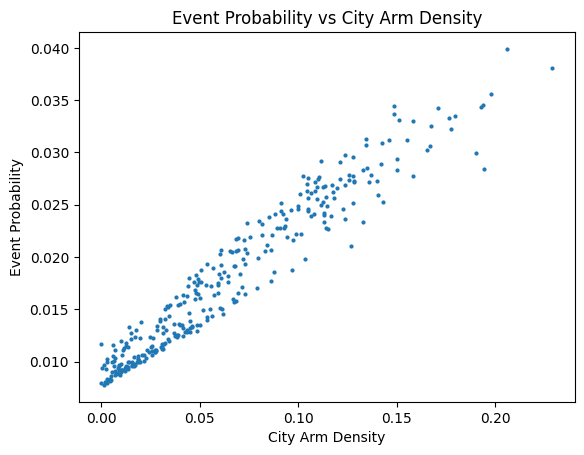

In [22]:
import matplotlib.pyplot as plt
plt.scatter(city_arm_density[~has_event], event_prob_mean[~has_event], s=4, marker='o', linestyle='None')
# plt.errorbar(city_arm_density, event_prob_mean, yerr=event_prob_std, fmt='o', capsize=5)
plt.xlabel('City Arm Density')
plt.ylabel('Event Probability')
plt.title('Event Probability vs City Arm Density')
plt.show()